# 🎓 Lost in Transition: A Global Study on Student Dropout Rates

---

**Project Title:** Lost in Transition – A Global Study on Student Dropout Rates  
**Data Source:** [World Bank – Education Statistics](https://data.worldbank.org/topic/4)  
**Focus Country:** 🇮🇳 India (used as a recurring case study throughout)  
**Description:** Despite high primary enrollment around the world, a critical "dropout cliff" occurs during the transition from primary to secondary — and again from secondary to tertiary education. This project uses World Bank education data to quantify this attrition and identify the scale of the global retention gap, with a **special focus on India** to understand where the country stands compared to the world and its regional peers.

---

### 📋 How This Notebook Is Organised

This notebook is divided into **6 Milestones**, each building on the previous one:

| Milestone | What It Covers |
|-----------|---------------|
| **1** | Problem Identification & Objective Definition |
| **2** | Data Acquisition & Initial Exploration |
| **3** | Exploratory Data Analysis – Part 1 (Univariate & Bivariate) |
| **4** | Exploratory Data Analysis – Part 2 (Multivariate & Segmentation) |
| **5** | Data Preparation, Insight Extraction & Dashboarding |
| **6** | Reporting, Presentation & Final Documentation |


In [10]:
# Load the three enrollment CSV files


import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# --- Load each file (skip the first 4 metadata rows) ---
# If you named your files differently, just change the filenames below.

primary   = pd.read_csv(r"D:\project\school_enrollment_primary.csv",   skiprows=4)
secondary = pd.read_csv(r"D:\project\school_enrollment_secondary.csv", skiprows=4)
tertiary  = pd.read_csv(r"D:\project\school_enrollment_tertiary.csv",  skiprows=4)

print("✅ Files loaded successfully!")
print(f"   Primary  : {primary.shape[0]} rows × {primary.shape[1]} columns")
print(f"   Secondary: {secondary.shape[0]} rows × {secondary.shape[1]} columns")
print(f"   Tertiary : {tertiary.shape[0]} rows × {tertiary.shape[1]} columns")


✅ Files loaded successfully!
   Primary  : 266 rows × 70 columns
   Secondary: 266 rows × 70 columns
   Tertiary : 266 rows × 70 columns


In [11]:
# Preview the raw data

print("=== Column names in the Primary enrollment file ===")
print(primary.columns.tolist()[:10], "... and more year columns")

print("\n=== First 3 rows ===")
primary.head(3)


=== Column names in the Primary enrollment file ===
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965'] ... and more year columns

=== First 3 rows ===


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"School enrollment, primary (% gross)",SE.PRM.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,113.637464,NaN,107.985168,108.025002,107.235336,108.599510,102.620728,NaN,107.716997,NaN
1,Africa Eastern and Southern,AFE,"School enrollment, primary (% gross)",SE.PRM.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,100.342110,101.228409,102.624809,103.610619,104.591942,103.366081,100.508301,100.85759,101.309242,NaN
2,Afghanistan,AFG,"School enrollment, primary (% gross)",SE.PRM.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,106.784042,106.543541,107.687660,109.075310,NaN,NaN,NaN,NaN,NaN,NaN


## Preproccessing and Feature Engnireening 


In [12]:
#   Reshape from Wide → Long and Merge

#Define the year columns we want 
year_cols = [str(y) for y in range(2000, 2024)]

# Keep only the columns we need
id_cols = ["Country Name", "Country Code"]

primary_subset   = primary[id_cols + [c for c in year_cols if c in primary.columns]]
secondary_subset = secondary[id_cols + [c for c in year_cols if c in secondary.columns]]
tertiary_subset  = tertiary[id_cols + [c for c in year_cols if c in tertiary.columns]]

# Melt (reshape wide → long)
# "melt" turns columns (2000, 2001, ...) into rows

primary_long = primary_subset.melt(
    id_vars=id_cols,
    var_name="Year",
    value_name="Primary_Enrollment"
)

secondary_long = secondary_subset.melt(
    id_vars=id_cols,
    var_name="Year",
    value_name="Secondary_Enrollment"
)

tertiary_long = tertiary_subset.melt(
    id_vars=id_cols,
    var_name="Year",
    value_name="Tertiary_Enrollment"
)

# Convert Year to integer
primary_long["Year"]   = primary_long["Year"].astype(int)
secondary_long["Year"] = secondary_long["Year"].astype(int)
tertiary_long["Year"]  = tertiary_long["Year"].astype(int)

# Merge all three on Country + Year
merged = primary_long.merge(secondary_long, on=["Country Name", "Country Code", "Year"])
merged = merged.merge(tertiary_long, on=["Country Name", "Country Code", "Year"])

print(f"✅ Merged dataset shape: {merged.shape}")
print(f"   {merged['Country Name'].nunique()} unique countries/regions")
print(f"   Years: {merged['Year'].min()} to {merged['Year'].max()}")
merged.head()

✅ Merged dataset shape: (6384, 6)
   266 unique countries/regions
   Years: 2000 to 2023


,Country Name,Country Code,Year,Primary_Enrollment,Secondary_Enrollment,Tertiary_Enrollment
0,Aruba,ABW,2000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,2000,78.762817,27.737129,3.99449
2,Afghanistan,AFG,2000,21.457850,NaN,NaN
3,Africa Western and Central,AFW,2000,80.579514,22.339140,4.95100
4,Angola,AGO,2000,NaN,13.369070,NaN


In [34]:
#Feature Selection + Data Enrichment 
#Load and merge country metadata
#Why we are doing this..?
#The World Bank classifies every country by **Region** (e.g., South Asia, Sub-Saharan Africa) 
# and **Income Group** (e.g., Low income, High income). This metadata comes in a file called `Metadata_Country.csv`

metadata = pd.read_csv(r"D:\project\Metadata_Country.csv")

print("Metadata columns:", metadata.columns.tolist())
print(f"Rows: {metadata.shape[0]}\n")

# Keep only the columns we need
metadata = metadata[["Country Code", "Region", "IncomeGroup"]]

# Merge with our main dataset
merged = merged.merge(metadata, on="Country Code", how="left")

# Preview
print("✅ Metadata merged. Sample rows:")
merged[["Country Name", "Country Code", "Year", "Region", "IncomeGroup"]].head()

Metadata columns: ['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName', 'Unnamed: 5']
Rows: 265

✅ Metadata merged. Sample rows:


,Country Name,Country Code,Year,Region,IncomeGroup
0,Aruba,ABW,2000,Latin America & Caribbean,High income
1,Africa Eastern and Southern,AFE,2000,NaN,NaN
2,Afghanistan,AFG,2000,Middle East & North Africa,Low income
3,Africa Western and Central,AFW,2000,NaN,NaN
4,Angola,AGO,2000,Sub-Saharan Africa,Lower middle income


In [36]:
# Growth Rates (YoY Change)

# 1. Sort by Country and Year to ensure chronological order
df = df.sort_values(by=["Country Name", "Year"])

# 2. Group by Country and calculate percentage change
# .pct_change() is the Pandas tool for (Value_t - Value_t-1) / Value_t-1
df["Primary_Growth"]   = df.groupby("Country Name")["Primary_Enrollment"].pct_change() * 100
df["Secondary_Growth"] = df.groupby("Country Name")["Secondary_Enrollment"].pct_change() * 100
df["Tertiary_Growth"]  = df.groupby("Country Name")["Tertiary_Enrollment"].pct_change() * 100

# 3. Clean up the Growth Rate outliers
# Sometimes a massive jump (e.g., from 1% to 10%) can create a 900% growth rate which skews charts.
df["Primary_Growth"] = df["Primary_Growth"].clip(lower=-20, upper=20) 

print("✅ Growth rates calculated!")
print(df[["Country Name", "Year", "Primary_Enrollment", "Primary_Growth"]].head(10))

✅ Growth rates calculated!
     Country Name  Year  Primary_Enrollment  Primary_Growth
2     Afghanistan  2000           21.457850             NaN
268   Afghanistan  2001           22.139650        3.177396
534   Afghanistan  2002           73.401314       20.000000
800   Afghanistan  2003           95.335747       20.000000
1066  Afghanistan  2004          105.475052       10.635365
1332  Afghanistan  2005           99.503906       -5.661192
1598  Afghanistan  2006          102.284866        2.794825
1864  Afghanistan  2007           99.322899       -2.895802
2130  Afghanistan  2008          104.445137        5.157157
2396  Afghanistan  2009           99.705421       -4.537995


In [35]:
#Data quality overview

print("-" * 60)
print("                      DATA QUALITY REPORT")
print("-" * 60)

print(f"\n📊 Dataset Dimensions: {merged.shape[0]:,} rows × {merged.shape[1]} columns")
print(f"🌍 Countries/Regions:  {merged['Country Name'].nunique()}")
print(f"📅 Year Range:         {merged['Year'].min()} – {merged['Year'].max()}")

print("\n--- Missing Values ---")
missing = merged.isnull().sum()
missing_pct = (merged.isnull().sum() / len(merged) * 100).round(1)
quality_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(quality_df)

print("\n--- Data Types ---")
print(merged.dtypes)


------------------------------------------------------------
                      DATA QUALITY REPORT
------------------------------------------------------------

📊 Dataset Dimensions: 6,384 rows × 12 columns
🌍 Countries/Regions:  266
📅 Year Range:         2000 – 2023

--- Missing Values ---
                      Missing Count  Missing %
Country Name                      0        0.0
Country Code                      0        0.0
Year                              0        0.0
Primary_Enrollment             1282       20.1
Secondary_Enrollment           1790       28.0
Tertiary_Enrollment            2218       34.7
Region_x                       1176       18.4
IncomeGroup_x                  1224       19.2
Region_y                       1176       18.4
IncomeGroup_y                  1224       19.2
Region                         1176       18.4
IncomeGroup                    1224       19.2

--- Data Types ---
Country Name             object
Country Code             object
Year      

In [15]:
# Save the raw merged dataset

merged.to_csv("raw_education_dataset.csv", index=False)
print("✅ Raw dataset saved as 'raw_education_dataset.csv'")
print(f"   Size: {merged.shape[0]:,} rows × {merged.shape[1]} columns")

✅ Raw dataset saved as 'raw_education_dataset.csv'
   Size: 6,384 rows × 8 columns


# Exploratory Data Analysis (Part 1: Univariate & Bivariate)
What is EDA?
Exploratory Data Analysis (EDA) is the process of examining your data through statistics and charts before building any models or drawing final conclusions. Think of it as "getting to know your data."

What is Univariate Analysis?
Looking at one variable at a time — its distribution, central tendency, and spread.

What is Bivariate Analysis?
Looking at the relationship between two variables — does one go up when the other goes up?

In [16]:
#  Setup for EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Drop rows where ALL THREE enrollment values are missing
# (If at least one level has data, we keep the row)
df = merged.dropna(
    subset=["Primary_Enrollment", "Secondary_Enrollment", "Tertiary_Enrollment"],
    how="all"
).copy()

print(f"✅ Working dataset: {df.shape[0]:,} rows (dropped {merged.shape[0] - df.shape[0]:,} fully-empty rows)")

✅ Working dataset: 5,285 rows (dropped 1,099 fully-empty rows)


In [47]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# We only scale the numerical enrollment columns
cols_to_scale = ["Primary_Enrollment", "Secondary_Enrollment", "Tertiary_Enrollment"]

# Create a copy so we don't overwrite the original 'df'
df_scaled = df.copy()

# ------------------------------------------------------------
# Option A: Min-Max Scaling (Range 0 to 1)
# ------------------------------------------------------------
min_max_scaler = MinMaxScaler()
df_scaled[[c + "_MinMax" for c in cols_to_scale]] = min_max_scaler.fit_transform(df[cols_to_scale])

# ------------------------------------------------------------
# Option B: Standardization (Z-score)
# ------------------------------------------------------------
std_scaler = StandardScaler()
df_scaled[[c + "_Std" for c in cols_to_scale]] = std_scaler.fit_transform(df[cols_to_scale])

print("✅ Scaling Complete!")
print(df_scaled[[ "Primary_Enrollment", "Primary_Enrollment_MinMax", "Primary_Enrollment_Std"]].head())
print("-"*80)
print(df_scaled[["Tertiary_Enrollment", "Tertiary_Enrollment_MinMax", "Tertiary_Enrollment_Std"]].head())
print("-"*80)
print(df_scaled[["Secondary_Enrollment", "Secondary_Enrollment_MinMax", "Secondary_Enrollment_Std"]].head())

✅ Scaling Complete!
      Primary_Enrollment  Primary_Enrollment_MinMax  Primary_Enrollment_Std
2              21.457850                   0.003325               -6.269039
268            22.139650                   0.007506               -6.215512
534            73.401314                   0.321853               -2.191044
800            95.335747                   0.456359               -0.469008
1066          105.475052                   0.518535                0.327012
--------------------------------------------------------------------------------
      Tertiary_Enrollment  Tertiary_Enrollment_MinMax  Tertiary_Enrollment_Std
2                     NaN                         NaN                      NaN
268                   NaN                         NaN                      NaN
534                   NaN                         NaN                      NaN
800               1.37435                    0.007553                -1.325724
1066              1.39064                    0.0

### What is the 

| Metric | If the value is 0 | If the value is 1 | If the value is Negative |
| :--- | :--- | :--- | :--- |
| **Min-Max** | Worst in the world. | Best in the world. | Not possible. |
| **Standardization** | Exactly Average. | 1 Step above average. | Below Average. |

## Summary Statistics (Descriptive Statistics)

Summary statistics give us a quick numerical snapshot of each variable. The key measures are:

| Statistic | What It Tells You |
|-----------|--------------------|
| **Mean** | The average value |
| **Median** | The middle value (50th percentile) — less affected by outliers than the mean |
| **Mode** | The most frequently occurring value |
| **Std Dev** | How spread out the values are |
| **IQR** | The range of the middle 50% of values (Q3 − Q1) |
| **Min / Max** | The smallest and largest values |

In [17]:
# Summary Statistics


enrollment_cols = ["Primary_Enrollment", "Secondary_Enrollment", "Tertiary_Enrollment"]

# Basic describe
print("--- Built-in describe() ---\n")
print(df[enrollment_cols].describe().round(2))

# Extended summary
print("\n\n--- Extended Summary Statistics ---\n")
summary = pd.DataFrame(index=enrollment_cols)
summary["Mean"]   = df[enrollment_cols].mean().round(2)
summary["Median"] = df[enrollment_cols].median().round(2)
summary["Mode"]   = df[enrollment_cols].mode().iloc[0].round(2)
summary["Std Dev"]= df[enrollment_cols].std().round(2)
summary["IQR"]    = (df[enrollment_cols].quantile(0.75) - df[enrollment_cols].quantile(0.25)).round(2)
summary["Min"]    = df[enrollment_cols].min().round(2)
summary["Max"]    = df[enrollment_cols].max().round(2)
summary["Non-Null Count"] = df[enrollment_cols].count()

print(summary)

--- Built-in describe() ---

       Primary_Enrollment  Secondary_Enrollment  Tertiary_Enrollment
count             5102.00               4594.00              4166.00
mean               101.31                 79.72                38.05
std                 12.74                 28.06                27.67
min                 20.92                  3.35                 0.12
25%                 96.95                 60.81                13.36
50%                101.36                 86.54                32.46
75%                106.67                 99.69                59.59
max                183.99                164.08               166.67


--- Extended Summary Statistics ---

                        Mean  Median    Mode  Std Dev    IQR    Min     Max  \
Primary_Enrollment    101.31  101.36  100.00    12.74   9.71  20.92  183.99   
Secondary_Enrollment   79.72   86.54   25.44    28.06  38.89   3.35  164.08   
Tertiary_Enrollment    38.05   32.46    4.38    27.67  46.23   0.12  166.6

- **Primary enrollment** typically has the highest mean and median — most countries achieve near-universal primary schooling.  
- **Tertiary enrollment** has the lowest values and highest spread (std dev) — university access varies enormously across the world.  
- If the **mean > median**, the distribution is right-skewed (pulled up by some very high values).  
- If the **mean < median**, the distribution is left-skewed.
---

## Distribution Analysis — Histograms

A **histogram** shows how frequently different value ranges occur. It helps us see the "shape" of a variable — is it symmetric? Skewed? Does it have multiple peaks?

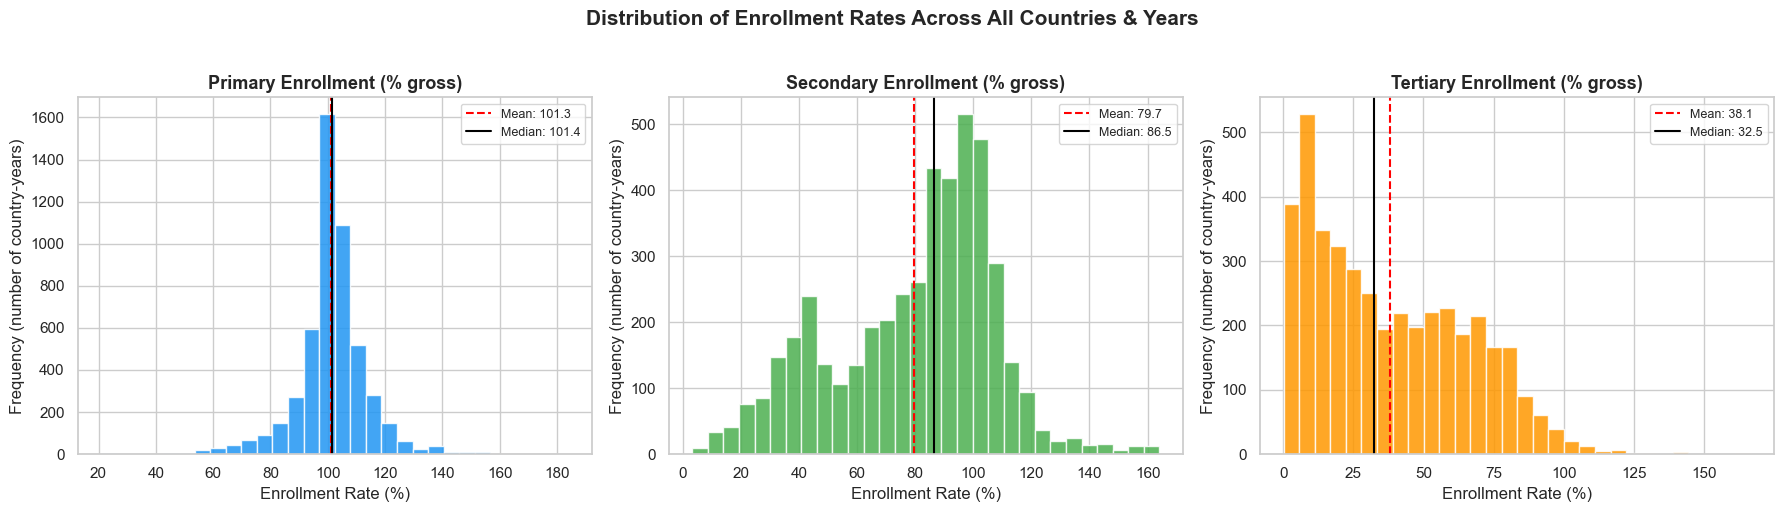

In [18]:
# Histograms for each enrollment level

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Primary Enrollment (% gross)", "Secondary Enrollment (% gross)", "Tertiary Enrollment (% gross)"]

for i, col in enumerate(enrollment_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=["#2196F3", "#4CAF50", "#FF9800"][i], 
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(titles[i], fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Enrollment Rate (%)")
    axes[i].set_ylabel("Frequency (number of country-years)")
    
    # Add mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.1f}")
    axes[i].axvline(median_val, color="black", linestyle="-", linewidth=1.5, label=f"Median: {median_val:.1f}")
    axes[i].legend(fontsize=9)

plt.suptitle("Distribution of Enrollment Rates Across All Countries & Years", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


- **Primary:** Most values cluster near 100 % → most countries have achieved near-universal primary enrollment. The distribution is **left-skewed** (a tail stretching to the left for countries with lower enrollment).
- **Secondary:** More spread out, with values ranging from ~20% to over 100%. The distribution is roughly **bell-shaped** but with variation.
- **Tertiary:** Heavily **right-skewed** — a large number of countries have very low tertiary enrollment (under 30%), while a few wealthy nations have very high rates.

> This pattern is the "dropout cliff" in action: high enrollment at primary, lower at secondary, much lower at tertiary.
> 
----

## Box Plots — Spotting the Spread and Outliers

A **box plot** shows five key statistics at a glance: minimum, Q1 (25th percentile), median, Q3 (75th percentile), and maximum. Points beyond the "whiskers" are potential **outliers**.

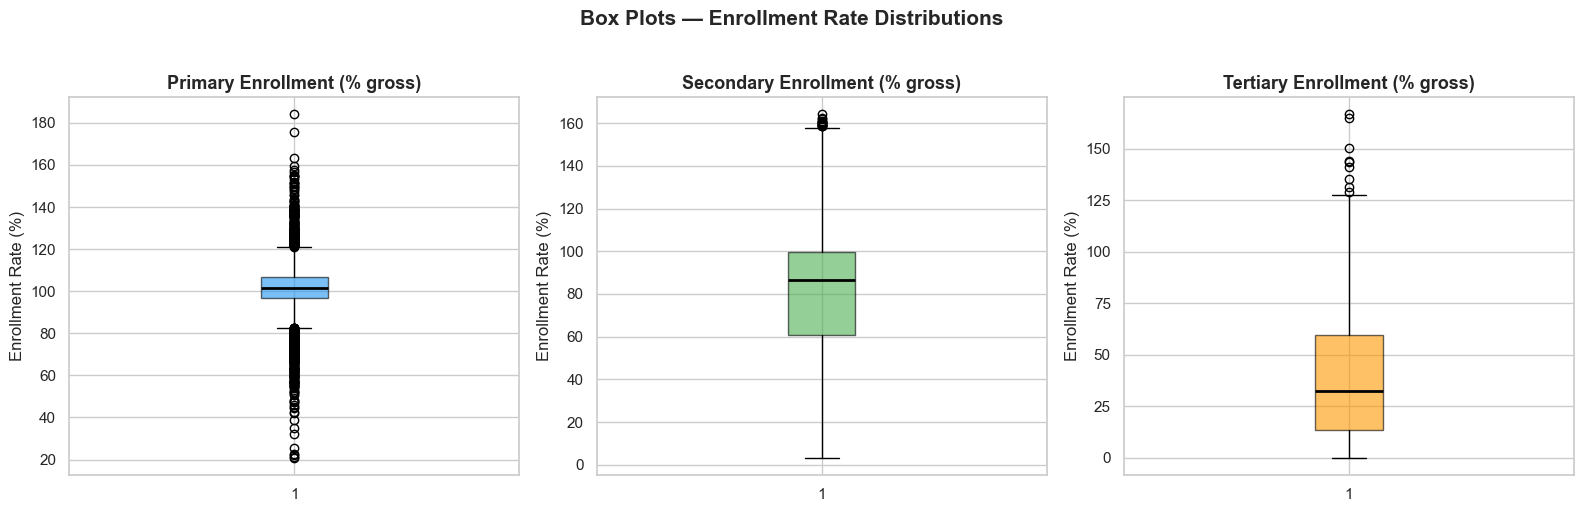

In [19]:
# Box Plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for i, col in enumerate(enrollment_cols):
    bp = axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor=colors[i], alpha=0.6),
                         medianprops=dict(color="black", linewidth=2))
    axes[i].set_title(titles[i], fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Enrollment Rate (%)")

plt.suptitle("Box Plots — Enrollment Rate Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- The **box** covers the middle 50 % of the data (from Q1 to Q3).
- The **line inside the box** is the median.
- The **whiskers** extend to 1.5 × IQR from the box edges.
- **Dots beyond the whiskers** are outliers — unusually high or low values.

Note --how tertiary enrollment has the longest box (most spread) and primary has the shortest (most countries are clustered together).

---

## Frequency Table for Categorical Variables

Our dataset has two categorical (text) variables: **Region** and **IncomeGroup**. Let's see how many data points (country-years) we have for each category.

In [26]:
#  Frequency Tables


print("--- Records by Region ---\n")
region_counts = df["Region"].value_counts()
print(region_counts)

print("\n\n--- Records by Income Group ---\n")
income_counts = df["IncomeGroup"].value_counts()
print(income_counts)


--- Records by Region ---

Region
Europe & Central Asia         1174
Sub-Saharan Africa             925
Latin America & Caribbean      782
East Asia & Pacific            638
Middle East & North Africa     468
South Asia                     143
North America                   51
Name: count, dtype: int64


--- Records by Income Group ---

IncomeGroup
High income            1554
Upper middle income    1110
Lower middle income    1034
Low income              443
Name: count, dtype: int64


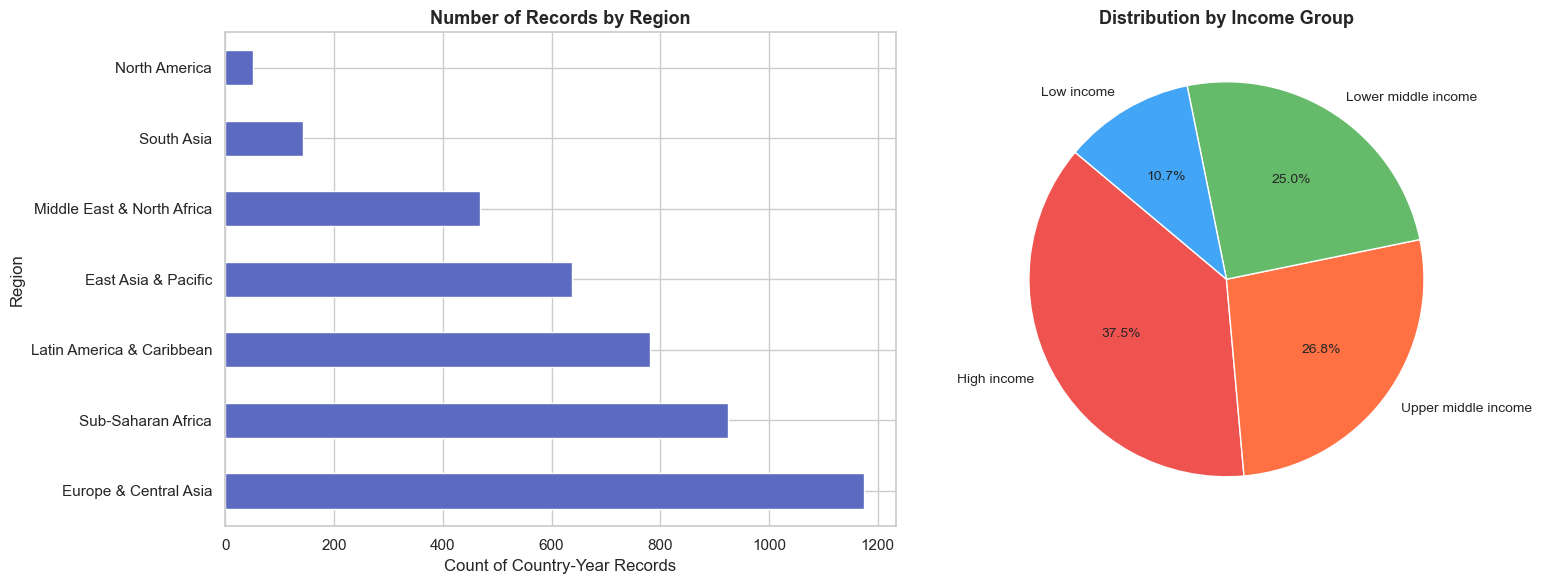

In [27]:
#  Bar chart for Region and Pie chart for IncomeGroup

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — Region
region_counts.plot(kind="barh", ax=axes[0], color="#5C6BC0", edgecolor="white")
axes[0].set_title("Number of Records by Region", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count of Country-Year Records")

# Pie chart — Income Group
colors_pie = ["#EF5350", "#FF7043", "#66BB6A", "#42A5F5"]
income_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", colors=colors_pie,
                   startangle=140, textprops={"fontsize": 10})
axes[1].set_title("Distribution by Income Group", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Outlier Detection and Treatment (IQR Method)

**What is an outlier?**  
An outlier is a data point that is far away from the majority of the data. It can be a genuine extreme value or a data error.

**The IQR method:**
- Calculate Q1 (25th percentile) and Q3 (75th percentile).
- IQR = Q3 − Q1
- Any value **below Q1 − 1.5 × IQR** or **above Q3 + 1.5 × IQR** is flagged as an outlier.

In [28]:
#  Outlier Detection using IQR method

print("=== Outlier Detection (IQR Method) ===\n")

outlier_summary = []

for col in enrollment_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct = (n_outliers / len(data) * 100)
    
    outlier_summary.append({
        "Variable": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outlier Count": n_outliers,
        "Outlier %": round(pct, 1)
    })
    print(f"{col}:")
    print(f"  Bounds: [{lower:.1f}, {upper:.1f}]")
    print(f"  Outliers: {n_outliers} ({pct:.1f}% of non-null values)\n")

outlier_df = pd.DataFrame(outlier_summary)
outlier_df


=== Outlier Detection (IQR Method) ===

Primary_Enrollment:
  Bounds: [82.4, 121.2]
  Outliers: 558 (10.9% of non-null values)

Secondary_Enrollment:
  Bounds: [2.5, 158.0]
  Outliers: 15 (0.3% of non-null values)

Tertiary_Enrollment:
  Bounds: [-56.0, 128.9]
  Outliers: 9 (0.2% of non-null values)



,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Primary_Enrollment,96.95,106.67,9.71,82.39,121.23,558,10.9
1,Secondary_Enrollment,60.81,99.69,38.89,2.47,158.03,15,0.3
2,Tertiary_Enrollment,13.36,59.59,46.23,-55.99,128.94,9,0.2


## Outlier Treatment Decision

For this project, we will **keep the outliers** rather than remove them, because:
- Gross Enrollment Rates genuinely exceed 100 % in many countries (due to repeaters and over-age students).
- Low values (e.g., primary enrollment of 30 %) are real — they represent countries in crisis.
- Removing them would distort the global picture we are trying to understand.

> **General rule:** Only remove outliers if you have a strong reason to believe they are *errors*, not genuine extreme values.
---

## 3.7 Bivariate Analysis — How Do Variables Relate?

Now let's look at **pairs of variables**. The core question: *Does higher enrollment at one level predict higher enrollment at the next level?*

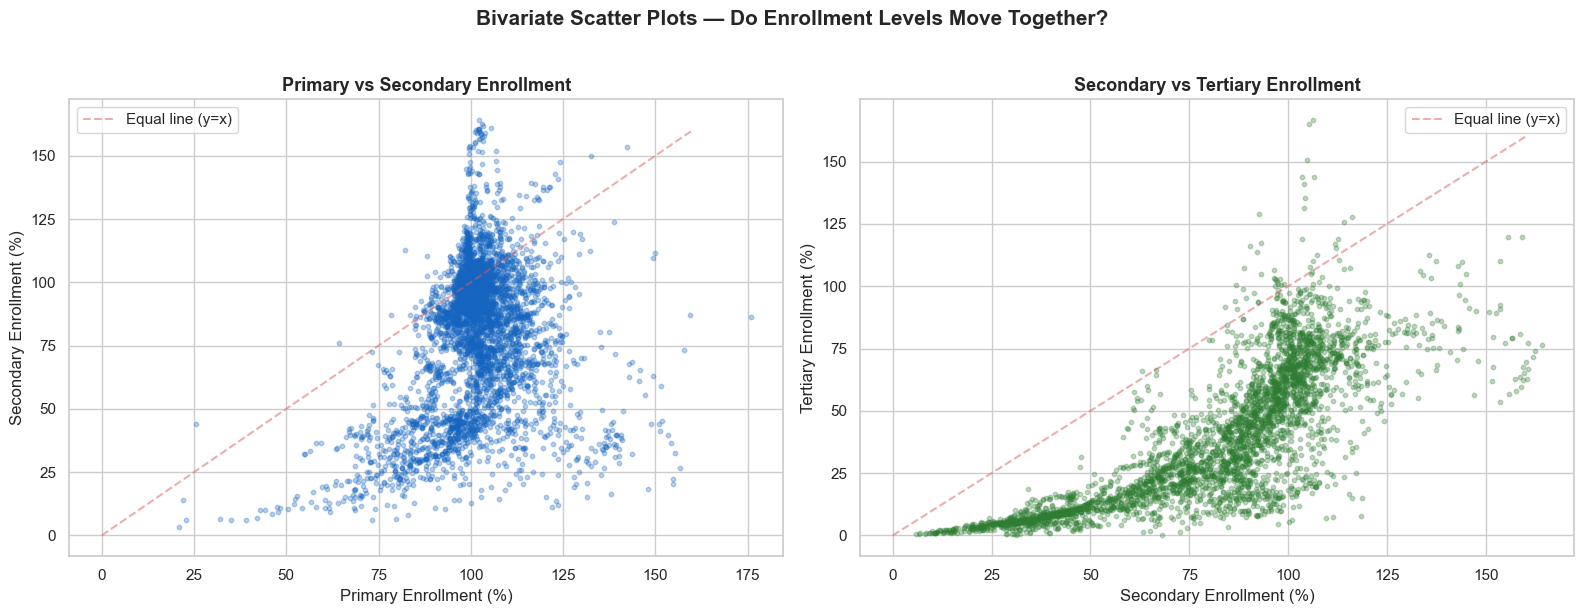

In [30]:
#   Scatter plots: Primary vs Secondary, Secondary vs Tertiary


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Primary vs Secondary
axes[0].scatter(df["Primary_Enrollment"], df["Secondary_Enrollment"], 
                alpha=0.3, s=10, color="#1565C0")
axes[0].set_xlabel("Primary Enrollment (%)", fontsize=12)
axes[0].set_ylabel("Secondary Enrollment (%)", fontsize=12)
axes[0].set_title("Primary vs Secondary Enrollment", fontsize=13, fontweight="bold")
# Add diagonal reference line
axes[0].plot([0, 160], [0, 160], "r--", alpha=0.5, label="Equal line (y=x)")
axes[0].legend()

# Secondary vs Tertiary
axes[1].scatter(df["Secondary_Enrollment"], df["Tertiary_Enrollment"], 
                alpha=0.3, s=10, color="#2E7D32")
axes[1].set_xlabel("Secondary Enrollment (%)", fontsize=12)
axes[1].set_ylabel("Tertiary Enrollment (%)", fontsize=12)
axes[1].set_title("Secondary vs Tertiary Enrollment", fontsize=13, fontweight="bold")
axes[1].plot([0, 160], [0, 160], "r--", alpha=0.5, label="Equal line (y=x)")
axes[1].legend()

plt.suptitle("Bivariate Scatter Plots — Do Enrollment Levels Move Together?", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the Scatter Plots

- The **red dashed line** represents y = x (perfect equality). If all points lay on this line, there would be zero dropout between levels.
- **Primary vs Secondary:** Most points are *below* the line → secondary enrollment is almost always lower than primary. The gap is the "dropout cliff."
- **Secondary vs Tertiary:** Points are *far below* the line → the drop from secondary to tertiary is even steeper.
- The further below the line, the larger the dropout gap for that country-year.